In [136]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy import signal

from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import factorial


import scipy.signal as signal



runfile = 'time_analysis_2_hour'

MAX_Q15 = 32767 / 32768
C1 = 99.90741625
C2 = 1225.60912165
C3 = 1024.0
C4 = 14.4



# Your known calibration points
# cal_adu = np.array([450, 1243, 12216])
# cal_kev = np.array([6.395, 14.4129, 122.06])

# # Calculate the quadratic fit (2nd-degree polynomial)
# a, b, c = np.polyfit(cal_adu, cal_kev, deg=2)

# print(f"a = {a:e}")
# print(f"b = {b:e}")
# print(f"c = {c:e}")


def adu_to_kev(adu):

    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    return a * (adu ** 2) + b * adu + c


def kev_to_adu(kev):
    a = -2.555374e-08
    b = 1.015411e-02
    c = 1.830826e+00
    
    # Calculate ADU using the positive root of the quadratic formula
    adu = (-b + np.sqrt(b**2 - 4 * a * (c - kev))) / (2 * a)
    
    return adu




MAX_Q15 = 32767 / 32768


raw = load_run(f"{runfile}/events_*.bin")
ts_us, energy, chb = unpack(raw)

print(f"{len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s" if len(ts_us) > 1 else "no events")
a, b, ppm = fit_clock(f"{runfile}/tiepoints.csv")
t_unix = counter_to_unix(ts_us, a, b)

9446834 events, span 7077.6 s


In [ ]:
interval_us = 5e4  # 100 ms in microseconds

Interval timestamps: (35388,)
Found 2192349 events in the 14.4-14.6 keV range.
Grouped into 35388 100-ms intervals.
Max events in a single 1s interval: 102


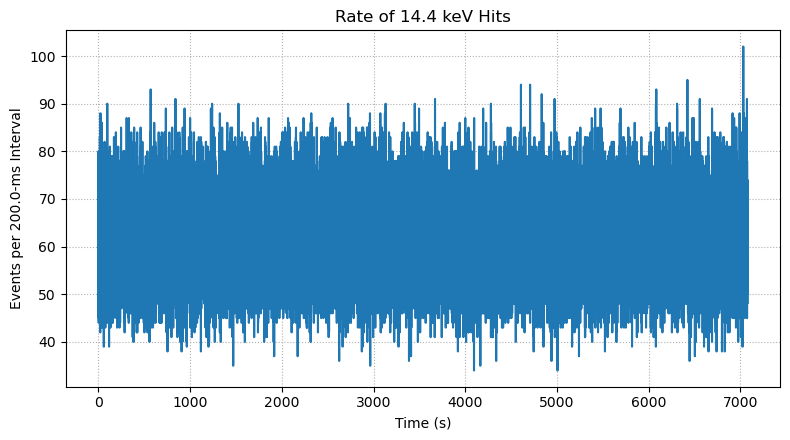

In [148]:

energy_kev = adu_to_kev(energy)

mask = (energy_kev >= 12.2) & (energy_kev <= 15.5)

# Output Array 1 & 2: Filtered energies and their corresponding times
filtered_energies = energy_kev[mask]
filtered_times_us = ts_us[mask]




start_time = ts_us[ts_us > 0][0]

end_time = ts_us[-1]

# Generate bin edges every 1000 us
time_bins = np.arange(start_time, end_time + interval_us, interval_us)

# Output Array 3: Calculate the frequency in each 1 ms interval
# np.histogram counts how many 'filtered_times_us' fall into each bin
frequencies, _ = np.histogram(filtered_times_us, bins=time_bins)

# (Optional) Get the corresponding timestamps for the frequencies (e.g., the start or center of the bin)
interval_timestamps = time_bins[:-1] 
print(f"Interval timestamps: {np.shape(interval_timestamps)}")
# plt.plot(interval_timestamps, frequencies, drawstyle='steps-post')
print(f"Found {len(filtered_energies)} events in the 14.4-14.6 keV range.")
print(f"Grouped into {len(frequencies)} 100-ms intervals.")
print(f"Max events in a single 1s interval: {np.max(frequencies)}")






# Interval unit conversions
interval_ms = interval_us / 1000.0
timestamps_s = interval_timestamps / 1e6  # Convert us to seconds for clean x-axis

plt.figure(figsize=(8, 4.5))
plt.plot(
    timestamps_s,
    frequencies
  
)

plt.xlabel("Time (s)")
plt.ylabel(f"Events per {interval_ms:.1f}-ms Interval")
plt.title(f"Rate of 14.4 keV Hits")
plt.grid(True, linestyle=":")
# plt.legend(loc="upper right")
plt.tight_layout()
# plt.savefig('rate', transparent=True, bbox_inches='tight')

plt.show()



In [150]:
# interval_timestamps[:-1]-interval_timestamps[1:]
# time_bins
average_frequency = np.mean(frequencies)
print(f"Average frequency: {average_frequency:.2f} events per 1 s interval.")

Average frequency: 61.95 events per 1 s interval.


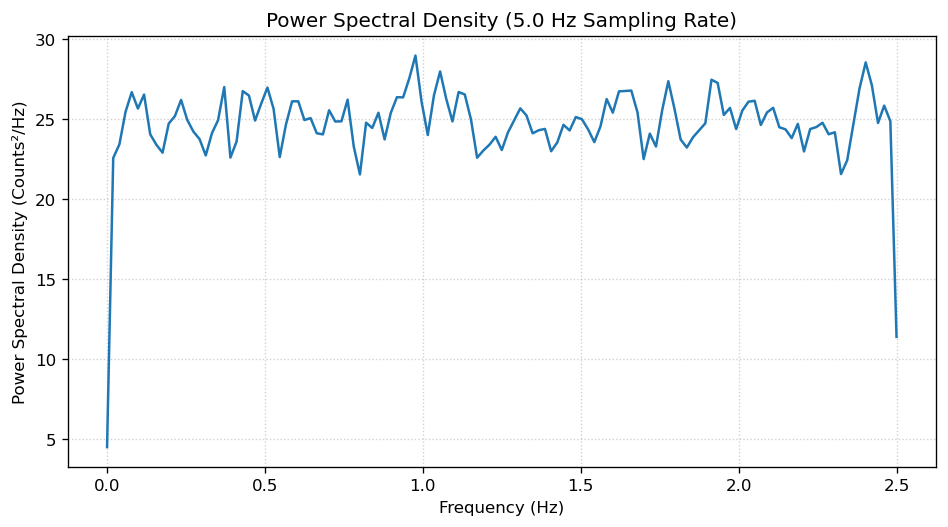

In [151]:

fs = 1e6 / interval_us

nperseg = min(len(frequencies) // 8, 256) if len(frequencies) > 0 else 256
f, psd = signal.welch(frequencies, fs=fs, nperseg=nperseg)


plt.figure(figsize=(8, 4.5), dpi=120)

plt.plot(f, psd)


plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density (Counts²/Hz)")
plt.title(f"Power Spectral Density ({fs:.1f} Hz Sampling Rate)")
plt.grid(True, which="both", linestyle=":", alpha=0.6)
# plt.savefig('fourier', transparent=True, bbox_inches='tight')

plt.tight_layout()
plt.show()


(0.1, 0.101)

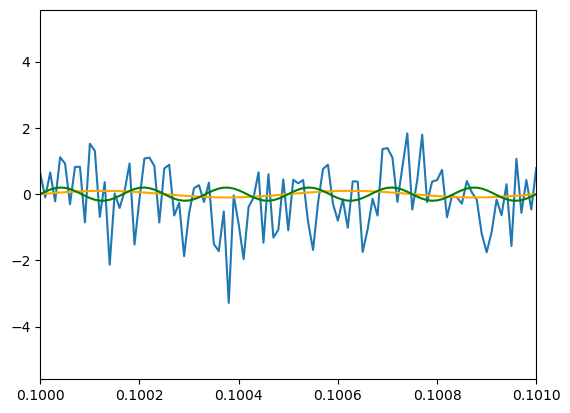

In [141]:
total_time = 10  # seconds
sampling_rate = 100000  # Hz

noise = np.random.normal(scale=1, size=int(total_time * sampling_rate)  )
frequency = 1000  # Frequency of the sine wave in Hz
axion = 0.1*np.sin(np.linspace(0, 20, int(total_time * sampling_rate))*2*np.pi*frequency)
axion2 = 0.2*np.sin(np.linspace(0, 20, int(total_time * sampling_rate))*2*np.pi*frequency*3)

measurement = axion + axion2 + noise
t = np.linspace(0, total_time, int(total_time * sampling_rate))
plt.plot(t, measurement)
plt.plot(t, axion, color='orange', label='Axion Signal')
plt.plot(t, axion2, color='green', label='Axion Signal 2')
plt.xlim(0.1,0.101)


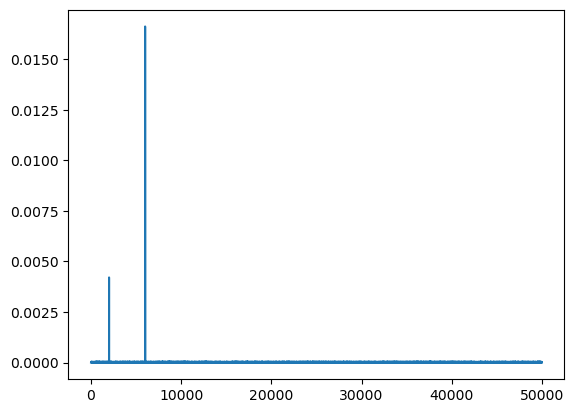

In [142]:
# f, psd_noise = signal.welch(noise, fs=sampling_rate, nperseg = len(measurement)//8)
f, psd = signal.welch(measurement, fs=sampling_rate, nperseg = len(measurement)//8)


plt.plot(f, psd)
#plt.plot(f, psd_noise)